In [1]:
# Lasso Regression on cleaned_property_data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load the cleaned dataset (update the path if needed)
df = pd.read_csv('cleaned_property_data.csv')

target_col = 'Super Buildup Rate (per sq.ft.)'
X = df.drop(columns=[target_col])
y = df[target_col]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Lasso regression model
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

# Predict
y_pred = lasso.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R2 Score:', r2)


Mean Squared Error: 0.528939218735583
R2 Score: 0.4217022180718931


In [4]:
import numpy as np
from sklearn.linear_model import LassoCV

alphas = np.logspace(-3, 3, 50)

# LassoCV automatically selects the best alpha using cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

print(f"Best alpha: {lasso_cv.alpha_}")
print(f"Train R² Score: {lasso_cv.score(X_train, y_train):.4f}")
print(f"Test R² Score: {lasso_cv.score(X_test, y_test):.4f}")

Best alpha: 0.001
Train R² Score: 0.9827
Test R² Score: 0.9802


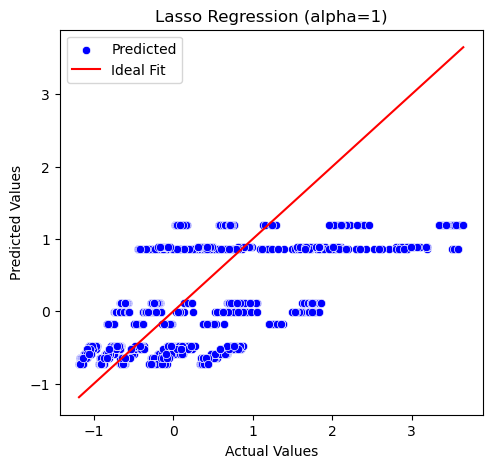

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))

# Lasso alpha = 1
plt.subplot(1,2,1)
sns.scatterplot(x=y_test, y=y_pred, color="blue", label="Predicted")
sns.lineplot(x=y_test, y=y_test, color="red", label="Ideal Fit")
plt.title("Lasso Regression (alpha=1)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

